In [1]:
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train = pd.read_csv("../data/train/X_train.csv")
X_test = pd.read_csv("../data/test/X_test.csv")

y_train = pd.read_csv("../data/train/y_train.csv").squeeze()
y_test = pd.read_csv("../data/test/y_test.csv").squeeze()

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [4]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:,1]

In [5]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
auc = roc_auc_score(y_test,y_prob)

print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)
print("ROC AUC  :",auc)

Accuracy : 0.7925467050387786
Precision: 0.19027181688125894
Recall   : 0.48217522658610273
F1 Score : 0.2728671567789366
ROC AUC  : 0.732331905424355


In [6]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88     56538
           1       0.19      0.48      0.27      4965

    accuracy                           0.79     61503
   macro avg       0.57      0.65      0.58     61503
weighted avg       0.89      0.79      0.83     61503



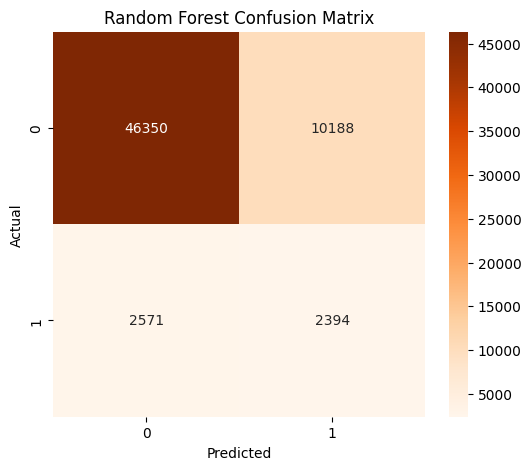

In [7]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [8]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                                  Feature  Importance
28                           EXT_SOURCE_3    0.117954
27                           EXT_SOURCE_2    0.115494
26                           EXT_SOURCE_1    0.047007
6                              DAYS_BIRTH    0.032254
7                           DAYS_EMPLOYED    0.028458
210                      EMPLOYMENT_YEARS    0.027423
61                 DAYS_LAST_PHONE_CHANGE    0.025620
4                         AMT_GOODS_PRICE    0.024997
2                              AMT_CREDIT    0.024160
209                             AGE_YEARS    0.024158
9                         DAYS_ID_PUBLISH    0.023613
3                             AMT_ANNUITY    0.022999
211                   CREDIT_INCOME_RATIO    0.020509
8                       DAYS_REGISTRATION    0.020396
212                  ANNUITY_INCOME_RATIO    0.019795
5              REGION_POPULATION_RELATIVE    0.016022
1                        AMT_INCOME_TOTAL    0.013579
106  NAME_EDUCATION_TYPE_Hig

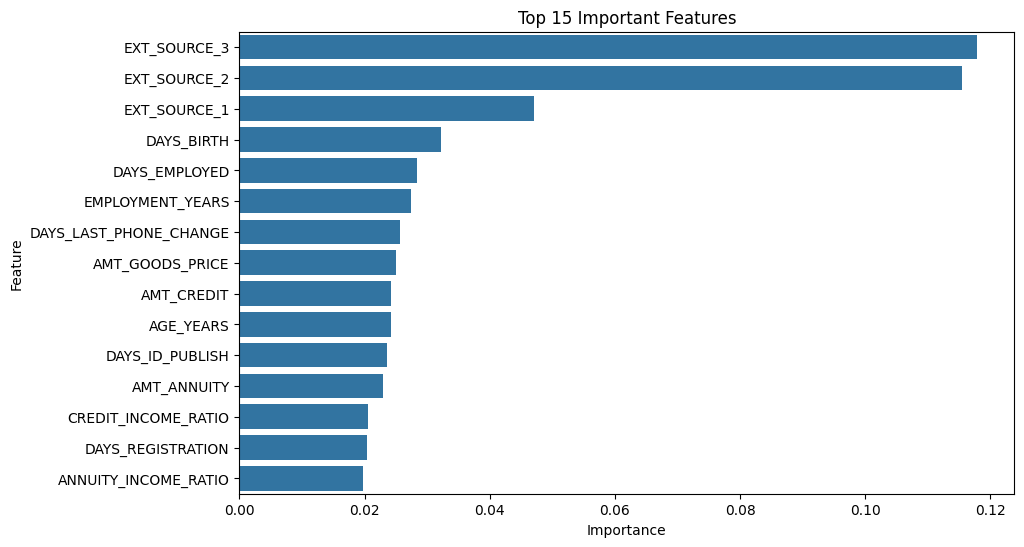

In [9]:
top15 = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top15,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [10]:
joblib.dump(rf_model,"../models/random_forest.pkl")

['../models/random_forest.pkl']